# Machine Learning: Exercise 1

- Id: 22302421
- Full name: Nguyễn Phúc Minh Châu

## Q1. Classification with k-Nearest Neighbors (kNN)

### Task 1
Load the Iris dataset and split it into training and testing sets with a ratio of 70% training and 30% testing.

In [1]:
from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import classification_report, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
data = load_iris()
X = data.data
y = data.target
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

### Task 2
Standardize the feature values using StandardScaler.

In [3]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

### Task 3
Train a kNN classifier with k = 5 using the training data.

In [4]:
K = 5
knn = KNeighborsClassifier(n_neighbors=K)
knn.fit(X_train_scaled, y_train)
y_pred = knn.predict(X_test_scaled)

### Task 4
Evaluate the model on the test set by:
•	Computing accuracy
•	Displaying the confusion matrix
•	Printing the classification report

Accuracy: 1.00
Classification Report:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00        19
           1       1.00      1.00      1.00        13
           2       1.00      1.00      1.00        13

    accuracy                           1.00        45
   macro avg       1.00      1.00      1.00        45
weighted avg       1.00      1.00      1.00        45



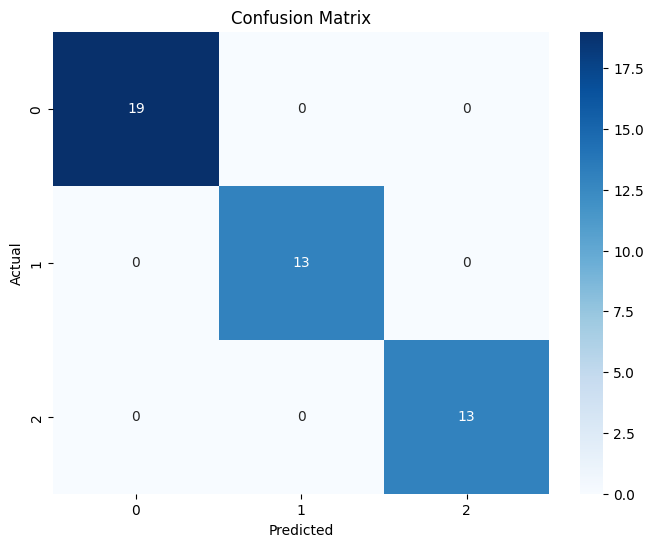

In [5]:
accuracy = knn.score(X_test_scaled, y_test)
print(f"Accuracy: {accuracy:.2f}")

print("Classification Report:")
print(classification_report(y_test, y_pred))

plt.figure(figsize=(8, 6))
sns.heatmap(confusion_matrix(y_test, y_pred), annot=True, fmt='d', cmap='Blues')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix')
plt.show()

### Task 5
Apply PCA to reduce the test data to 2 dimensions and visualize:

- Test samples colored by their predicted class
- A clear legend indicating each class

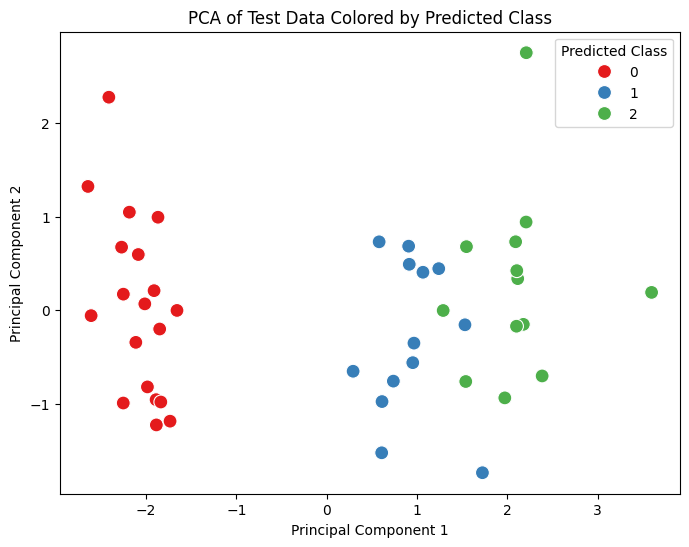

In [6]:
from sklearn.decomposition import PCA

pca = PCA(n_components=2)
X_test_pca = pca.fit_transform(X_test_scaled)

plt.figure(figsize=(8, 6))
sns.scatterplot(x=X_test_pca[:, 0], y=X_test_pca[:, 1], hue=y_pred, palette='Set1', s=100)
plt.title('PCA of Test Data Colored by Predicted Class')
plt.xlabel('Principal Component 1')
plt.ylabel('Principal Component 2')
plt.legend(title='Predicted Class')
plt.show()

## Q2. Regression

### Task 6
Generate a simple 1-dimensional synthetic dataset for regression.

In [7]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression

In [8]:
X = np.random.rand(100, 1) * 10  # 100 samples between 0 and 10
y = 2.5 * X.flatten() + np.random.randn(100) * 5  # Linear relation with some noise

### Task 7
Train a regression model (Linear Regression or kNN Regression).

In [9]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

model = LinearRegression()
model.fit(X_train, y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


### Task 8
Predict the output values for 5 newly generated data points.

In [10]:
#Predict the output values for 5 newly generated data points.
X_new = np.random.rand(5, 1) * 10
y_pred_new = model.predict(X_new)
print("Predicted values for new data points:", y_pred_new)

Predicted values for new data points: [18.8492411  11.36688361  6.6726745   3.70401802  0.60748335]


### Task 9
Plot:
- Training data points
- Regression line
- Predicted points for the new data

Explain the role of reshape(-1, 1) in preparing the input data.

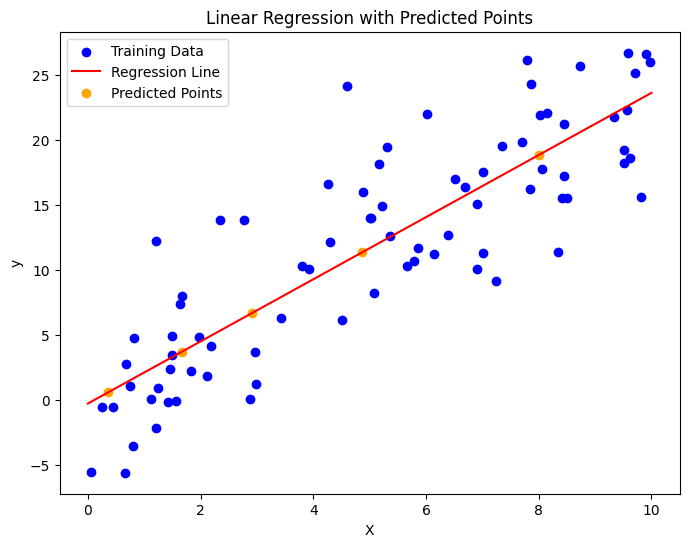

In [11]:
plt.figure(figsize=(8, 6))
plt.scatter(X_train, y_train, color='blue', label='Training Data')
x_line = np.linspace(0, 10, 100).reshape(-1, 1)
y_line = model.predict(x_line)
plt.plot(x_line, y_line, color='red', label='Regression Line')
plt.scatter(X_new, y_pred_new, color='orange', label='Predicted Points')
plt.title('Linear Regression with Predicted Points')
plt.xlabel('X')
plt.ylabel('y')
plt.legend()
plt.show()